In [44]:
import torch
from torch.utils.data import Dataset, DataLoader
# imagefolder
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from tqdm import tqdm

In [45]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    # Normalize the images to have mean = 0 and std of 1 for each channel
    # transforms.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0]),
    # transforms.RandomHorizontalFlip(p=0.5),  # randomly flip images horizontally with a probability of 0.5

])

In [46]:
class ImgTxtClassifier(torch.nn.Module):
    def __init__(self):
        super(ImgTxtClassifier, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = torch.nn.Linear(32 * 32 * 32, 128)
        self.fc2 = torch.nn.Linear(128, 2)  # binary classification

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)  # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = ImgTxtClassifier()

In [47]:
# inference

# step 1 is to load the model and the state dict
model = ImgTxtClassifier()
model.load_state_dict(torch.load(r"D:\NeuralNetworks-ML-AI\image_classifier\img_txt_classifier.pth"))

# step 2 is to set the model to evaluation mode
model.eval()

# path of the image to be classified
from PIL import Image
path = r"C:\Users\101119\Pictures\screenshots\Screenshot 2023-08-08 115445.png"
# path = r"D:\NeuralNetworks-ML-AI\image_classifier\data\test\image\Screenshot 2026-06-12 154419.png"
# path = r"D:\NeuralNetworks-ML-AI\image_classifier\data\test\text\Screenshot 2025-08-14 085406.png"

# step 3 is to load the image and apply the same transformations as during training
image = Image.open(path).convert("RGB")
transformed_image = transform(image).unsqueeze(0)  # add batch dimension

# step 4 is to pass the image through the model and get the predicted class
with torch.no_grad():
    output = model(transformed_image)
    _, predicted_class = torch.max(output.data, 1)
    print("Predicted class:", predicted_class.item())
    # print("Predicted class name:", train_dataset.classes[predicted_class.item()])

Predicted class: 0


In [48]:
# # render each of the 16 channels of the first convolutional layer as a separate image
import matplotlib.pyplot as plt

# # get the weights of the first convolutional layer
# weights = model.conv1.weight.data.clone()
# # plot each channel
# for i in range(weights.size(0)):
#     plt.subplot(4, 4, i+1)
#     plt.imshow(weights[i].permute(1, 2, 0).numpy())
#     plt.axis('off')
# plt.show()

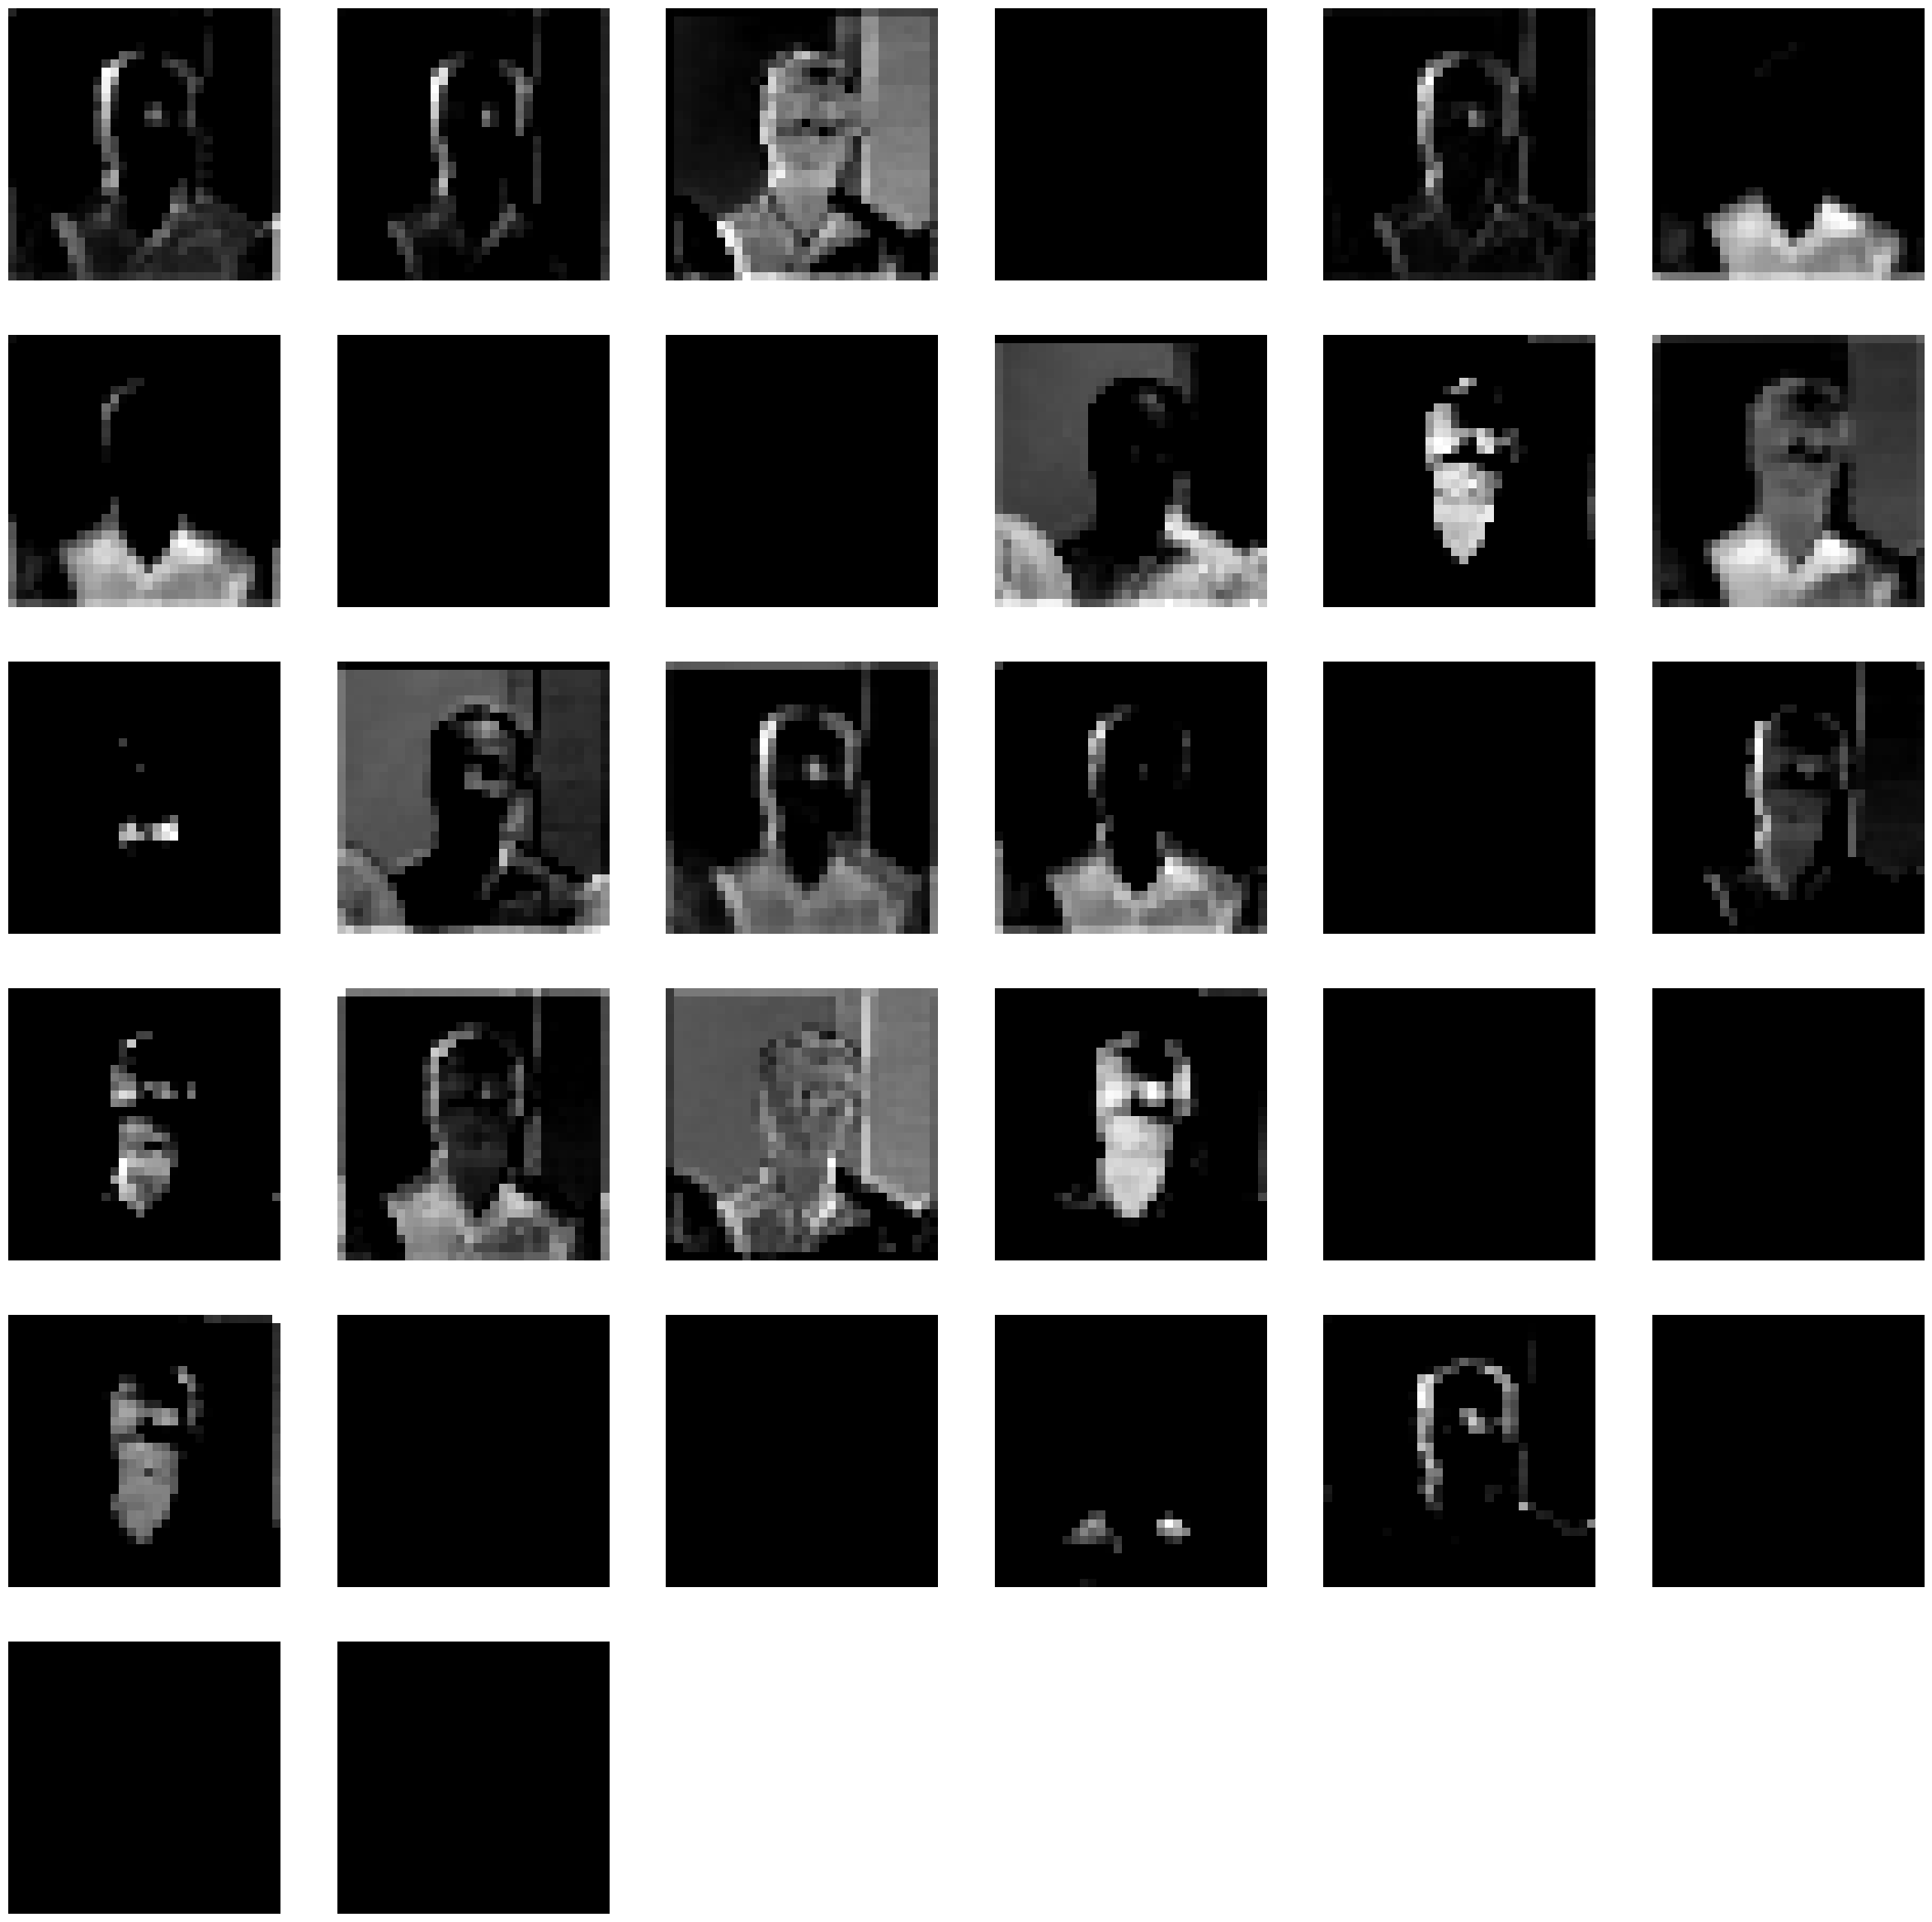

In [49]:
# render the output of the first convolutional layer for the input image, each channel as a separate image
plt.rcParams['figure.figsize'] = [30, 30]
with torch.no_grad():
    conv1_output = model.pool(torch.relu(model.conv1(transformed_image)))
    conv2_output = model.pool(torch.relu(model.conv2(conv1_output)))
    for i in range(conv2_output.size(1)):
        plt.subplot(6, 6, i+1)
        plt.imshow(conv2_output[0, i].numpy(), cmap='gray')
        plt.axis('off')
    plt.show()